# 🔧 Pre-processing Mitigation

Objectif : réduire les biais **avant** l'entraînement via rééchantillonnage, class weighting et augmentation des embeddings.

In [1]:
# Cellule 1: Setup
import os, json, pickle, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

if os.path.basename(os.getcwd()) != 'experiments':
    if (Path(os.getcwd()) / 'experiments').exists():
        os.chdir(Path(os.getcwd()) / 'experiments')
sys.path.insert(0, str(Path(os.getcwd()).parent / 'utils'))
from fairness_metrics import compute_fairness_metrics
print(f'📁 {os.getcwd()}')

RESULTS = Path('../results/phase4')
FIGS    = RESULTS / 'figures'
RESULTS.mkdir(parents=True, exist_ok=True)
FIGS.mkdir(parents=True, exist_ok=True)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
try:
    from imblearn.over_sampling import SMOTE
    from imblearn.under_sampling import RandomUnderSampler
    HAS_IMBLEARN = True
except ImportError:
    HAS_IMBLEARN = False
    print('⚠️  imbalanced-learn non installé — pip install imbalanced-learn')
    print('   SMOTE et undersampling seront ignorés')
print('✅ Setup OK')


📁 /Users/antoinedalle/Desktop/Period_3/Fair_AI/Projet/NLP_fairness_project/experiments
✅ Setup OK


In [2]:
# Cellule 2: Charger données
with open('models/label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)

def load_jsonl(p):
    rows = []
    with open(p, encoding='utf-8') as f:
        for l in f:
            if l.strip(): rows.append(json.loads(l))
    return rows

df_train = pd.DataFrame(load_jsonl('medical_bios_data/train.jsonl'))
df_val   = pd.DataFrame(load_jsonl('medical_bios_data/validation.jsonl'))
df_test  = pd.DataFrame(load_jsonl('medical_bios_data/test.jsonl'))
y_train  = le.transform(df_train['title'])
y_val    = le.transform(df_val['title'])
y_test   = le.transform(df_test['title'])
genders_train = df_train['gender'].values
genders_val   = df_val['gender'].values
genders_test  = df_test['gender'].values

# Embeddings du meilleur modèle
try:
    with open('../results/phase2/best_embedding_model.json') as f:
        best_info = json.load(f)
    model_id = best_info['model_id']
    print(f'📦 Embeddings: {best_info["label"]}')
except FileNotFoundError:
    model_id = 'distilroberta-base'

safe  = model_id.replace('/', '_')
CACHE = Path('embedding_cache')
emb_train = np.load(list(CACHE.glob(f'{safe}_{len(df_train)}*.npy'))[0])
emb_test  = np.load(list(CACHE.glob(f'{safe}_{len(df_test)}*.npy'))[0])

# Charger best RF params
try:
    with open('../results/phase2/best_rf_params.json') as f:
        rf_p = json.load(f)
except FileNotFoundError:
    rf_p = {'n_estimators': 100, 'max_depth': 20, 'min_samples_split': 2}

print(f'✅ Train={len(df_train)} | Test={len(df_test)} | Classes={list(le.classes_)}')


📦 Embeddings: DistilRoBERTa
✅ Train=8000 | Test=1000 | Classes=[np.str_('dentist'), np.str_('nurse'), np.str_('physician'), np.str_('psychologist'), np.str_('surgeon')]


In [3]:
# Cellule 3: Baseline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

def train_rf(X_tr, y_tr, params=rf_p):
    clf = RandomForestClassifier(
        n_estimators=params.get('n_estimators', 100),
        max_depth=params.get('max_depth', 20),
        min_samples_split=params.get('min_samples_split', 2),
        random_state=42, n_jobs=-1)
    clf.fit(X_tr, y_tr)
    return clf

# Baseline sans mitigation
rf_base = train_rf(emb_train, y_train)
pred_base = rf_base.predict(emb_test)
fm_base   = compute_fairness_metrics(y_test, pred_base, genders_test, le.classes_)
print('📊 BASELINE (sans mitigation):')
for k in ['accuracy','delta_dp','delta_eo','delta_eqodds']:
    print(f'  {k}: {fm_base[k]:.4f}')

def compare_and_plot(results_dict, title, fname):
    """results_dict = {label: fm_dict}"""
    keys = ['accuracy', 'delta_dp', 'delta_eo', 'delta_eqodds']
    df = pd.DataFrame({k: {lbl: v[k] for lbl, v in results_dict.items()} for k in keys})

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    df[['accuracy']].plot(kind='barh', ax=axes[0], color='steelblue', legend=False)
    axes[0].set_title('Accuracy')
    axes[0].axvline(fm_base['accuracy'], color='red', linestyle='--', label='Baseline')
    axes[0].legend()

    df[['delta_dp','delta_eo','delta_eqodds']].plot(kind='barh', ax=axes[1], colormap='Set1')
    axes[1].set_title('Fairness Gaps (↓ meilleur)')
    axes[1].axvline(fm_base['delta_dp'], color='gray', linestyle='--', alpha=0.5)

    plt.suptitle(title)
    plt.tight_layout()
    plt.savefig(FIGS / fname, dpi=150, bbox_inches='tight')
    plt.show()
    return df


📊 BASELINE (sans mitigation):
  accuracy: 0.8990
  delta_dp: 0.1741
  delta_eo: 0.1720
  delta_eqodds: 0.1720


## 1️⃣ Class Weighting (rapide, sans dépendance externe)

In [4]:
# Cellule 4: Class weighting — pondérer les groupes sous-représentés
# Construire des poids basés sur le genre × profession
results = {'Baseline': fm_base}

for strategy in ['balanced', 'balanced_subsample']:
    rf = RandomForestClassifier(
        n_estimators=rf_p.get('n_estimators',100),
        max_depth=rf_p.get('max_depth',20),
        min_samples_split=rf_p.get('min_samples_split',2),
        class_weight=strategy,
        random_state=42, n_jobs=-1)
    rf.fit(emb_train, y_train)
    preds = rf.predict(emb_test)
    fm = compute_fairness_metrics(y_test, preds, genders_test, le.classes_)
    results[f'class_weight={strategy}'] = fm
    print(f'  {strategy}: acc={fm["accuracy"]:.4f}  ∆DP={fm["delta_dp"]:.4f}  ∆EO={fm["delta_eo"]:.4f}')

# Sample weights manuels : sur-pondérer les minorités genre×profession
group_counts = pd.Series(list(zip(genders_train, df_train['title']))).value_counts()
sample_weights = np.array([
    1.0 / group_counts.get((g, t), 1)
    for g, t in zip(genders_train, df_train['title'])
])
sample_weights /= sample_weights.mean()  # normaliser

rf_sw = RandomForestClassifier(
    n_estimators=rf_p.get('n_estimators',100),
    max_depth=rf_p.get('max_depth',20),
    random_state=42, n_jobs=-1)
rf_sw.fit(emb_train, y_train, sample_weight=sample_weights)
preds_sw = rf_sw.predict(emb_test)
fm_sw = compute_fairness_metrics(y_test, preds_sw, genders_test, le.classes_)
results['sample_weight (genre×prof)'] = fm_sw
print(f'  sample_weight: acc={fm_sw["accuracy"]:.4f}  ∆DP={fm_sw["delta_dp"]:.4f}  ∆EO={fm_sw["delta_eo"]:.4f}')


  balanced: acc=0.9060  ∆DP=0.1772  ∆EO=0.2005
  balanced_subsample: acc=0.9030  ∆DP=0.1740  ∆EO=0.1767
  sample_weight: acc=0.9100  ∆DP=0.1697  ∆EO=0.1214


## 2️⃣ Resampling SMOTE + Undersampling

In [5]:
# Cellule 5: SMOTE et undersampling (nécessite imbalanced-learn)
if HAS_IMBLEARN:
    # Créer un label combiné genre×profession pour rééquilibrer les 2 dimensions
    gender_enc = (genders_train == 'Male').astype(int)  # 0=Female, 1=Male
    combined_label = y_train * 2 + gender_enc  # label unique par sous-groupe

    # SMOTE sur l'espace des embeddings
    smote = SMOTE(random_state=42, k_neighbors=5)
    emb_sm, label_sm = smote.fit_resample(emb_train, combined_label)
    y_sm = label_sm // 2  # récupérer label profession
    # gender_sm = label_sm % 2  # non utilisé pour l'entraînement

    rf_smote = RandomForestClassifier(
        n_estimators=rf_p.get('n_estimators',100),
        max_depth=rf_p.get('max_depth',20),
        random_state=42, n_jobs=-1)
    rf_smote.fit(emb_sm, y_sm)
    preds_sm = rf_smote.predict(emb_test)
    fm_sm = compute_fairness_metrics(y_test, preds_sm, genders_test, le.classes_)
    results['SMOTE (genre×prof)'] = fm_sm
    print(f'  SMOTE: acc={fm_sm["accuracy"]:.4f}  ∆DP={fm_sm["delta_dp"]:.4f}  ∆EO={fm_sm["delta_eo"]:.4f}')
    print(f'  Train size: {len(emb_train)} → {len(emb_sm)}')

    # Undersampling des groupes majoritaires
    rus = RandomUnderSampler(random_state=42)
    emb_us, label_us = rus.fit_resample(emb_train, combined_label)
    y_us = label_us // 2

    rf_us = RandomForestClassifier(
        n_estimators=rf_p.get('n_estimators',100),
        max_depth=rf_p.get('max_depth',20),
        random_state=42, n_jobs=-1)
    rf_us.fit(emb_us, y_us)
    preds_us = rf_us.predict(emb_test)
    fm_us = compute_fairness_metrics(y_test, preds_us, genders_test, le.classes_)
    results['Undersampling'] = fm_us
    print(f'  Undersampling: acc={fm_us["accuracy"]:.4f}  ∆DP={fm_us["delta_dp"]:.4f}  ∆EO={fm_us["delta_eo"]:.4f}')
    print(f'  Train size: {len(emb_train)} → {len(emb_us)}')
else:
    print('⏭️  SMOTE/Undersampling ignorés (imbalanced-learn absent)')


  SMOTE: acc=0.9170  ∆DP=0.1631  ∆EO=0.0969
  Train size: 8000 → 14860
  Undersampling: acc=0.8780  ∆DP=0.1496  ∆EO=0.0640
  Train size: 8000 → 1520


## 3️⃣ Data Augmentation par Bruit Gaussien

In [6]:
# Cellule 6: Augmentation des embeddings minoritaires
# Identifier les sous-groupes minoritaires (genre × profession)
subgroup_counts = pd.Series(list(zip(genders_train, y_train))).value_counts()
median_count = subgroup_counts.median()

augmented_embs, augmented_labels = [emb_train.copy()], [y_train.copy()]
noise_std = emb_train.std(axis=0).mean() * 0.05  # 5% du std moyen

n_added = 0
for (g, prof_id), count in subgroup_counts.items():
    if count < median_count:
        mask = (genders_train == g) & (y_train == prof_id)
        n_to_add = int(median_count - count)
        idx = np.random.choice(mask.sum(), n_to_add, replace=True)
        base_embs = emb_train[mask][idx]
        noise = np.random.normal(0, noise_std, base_embs.shape)
        augmented_embs.append(base_embs + noise)
        augmented_labels.append(np.full(n_to_add, prof_id))
        n_added += n_to_add

emb_aug = np.vstack(augmented_embs)
y_aug   = np.concatenate(augmented_labels)
print(f'  Ajouté {n_added} exemples synthétiques (bruit std={noise_std:.4f})')
print(f'  Train size: {len(emb_train)} → {len(emb_aug)}')

rf_aug = RandomForestClassifier(
    n_estimators=rf_p.get('n_estimators',100),
    max_depth=rf_p.get('max_depth',20),
    random_state=42, n_jobs=-1)
rf_aug.fit(emb_aug, y_aug)
preds_aug = rf_aug.predict(emb_test)
fm_aug = compute_fairness_metrics(y_test, preds_aug, genders_test, le.classes_)
results['Augmentation (bruit)'] = fm_aug
print(f'  Augmentation: acc={fm_aug["accuracy"]:.4f}  ∆DP={fm_aug["delta_dp"]:.4f}  ∆EO={fm_aug["delta_eo"]:.4f}')


  Ajouté 1572 exemples synthétiques (bruit std=0.0014)
  Train size: 8000 → 9572
  Augmentation: acc=0.9150  ∆DP=0.1650  ∆EO=0.1324


## 📊 Comparaison des Méthodes

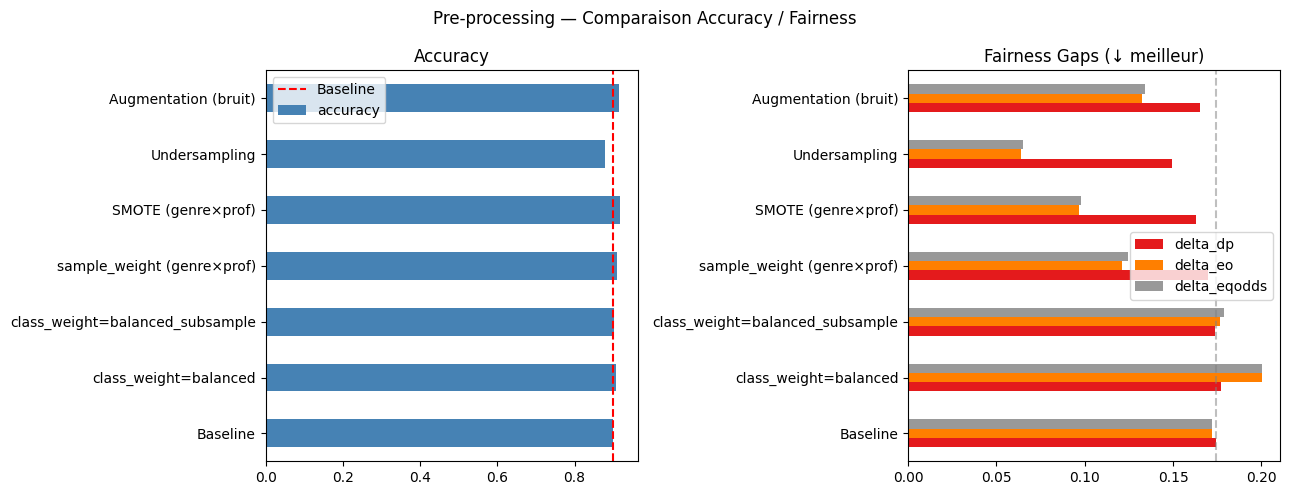


📊 TABLEAU RÉCAPITULATIF:
                                 accuracy  delta_dp  delta_eo  delta_eqodds  mean_gap
Baseline                            0.899    0.1741    0.1720        0.1720    0.1727
class_weight=balanced               0.906    0.1772    0.2005        0.2005    0.1928
class_weight=balanced_subsample     0.903    0.1740    0.1767        0.1790    0.1766
sample_weight (genre×prof)          0.910    0.1697    0.1214        0.1243    0.1385
SMOTE (genre×prof)                  0.917    0.1631    0.0969        0.0976    0.1192
Undersampling                       0.878    0.1496    0.0640        0.0652    0.0930
Augmentation (bruit)                0.915    0.1650    0.1324        0.1343    0.1439

🏆 Meilleur compromis: SMOTE (genre×prof)
💾 preprocessing_results.csv
🎉 Notebook 09 terminé!


In [7]:
# Cellule 7: Tableau + visualisation comparative
compare_df = compare_and_plot(results,
    'Pre-processing — Comparaison Accuracy / Fairness',
    'preprocessing_comparison.png')

compare_df['mean_gap'] = compare_df[['delta_dp','delta_eo','delta_eqodds']].mean(axis=1)
compare_df['composite'] = compare_df['accuracy'] - compare_df['mean_gap']

print('\n📊 TABLEAU RÉCAPITULATIF:')
print(compare_df[['accuracy','delta_dp','delta_eo','delta_eqodds','mean_gap']].round(4).to_string())

best = compare_df['composite'].idxmax()
print(f'\n🏆 Meilleur compromis: {best}')

compare_df.to_csv(RESULTS / 'preprocessing_results.csv')

# Sauvegarder le meilleur modèle pre-processing
best_model_map = {
    'class_weight=balanced': rf,
    'class_weight=balanced_subsample': rf,
    'sample_weight (genre×prof)': rf_sw,
    'Augmentation (bruit)': rf_aug,
}
if best in best_model_map:
    with open('models/best_preprocessing_model.pkl', 'wb') as f:
        pickle.dump(best_model_map[best], f)
    print(f'💾 models/best_preprocessing_model.pkl')

print('💾 preprocessing_results.csv')
print('🎉 Notebook 09 terminé!')
